In [ ]:
Assignment-9 27-06-2026 
Adarsh Rai 

In [ ]:
import re

email = "test@gmail.com"

if re.match(pattern, email):
    print("Valid Email")
else:
    print("Invalid Email")

In [5]:
import pandas as pd
df = pd.read_csv("customers.csv")
print(df.head())

   Index      Customer Id First Name Last Name  \
0      1  DD37Cf93aecA6Dc     Sheryl    Baxter   
1      2  1Ef7b82A4CAAD10    Preston    Lozano   
2      3  6F94879bDAfE5a6        Roy     Berry   
3      4  5Cef8BFA16c5e3c      Linda     Olsen   
4      5  053d585Ab6b3159     Joanna    Bender   

                           Company               City  \
0                  Rasmussen Group       East Leonard   
1                      Vega-Gentry  East Jimmychester   
2                    Murillo-Perry      Isabelborough   
3  Dominguez, Mcmillan and Donovan         Bensonview   
4         Martin, Lang and Andrade     West Priscilla   

                      Country                 Phone 1                Phone 2  \
0                       Chile            229.077.5154       397.884.0519x718   
1                    Djibouti              5153435776       686-620-1820x944   
2         Antigua and Barbuda         +1-539-402-0259    (496)978-3969x58947   
3          Dominican Republic  001-8

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Index              100 non-null    int64 
 1   Customer Id        100 non-null    object
 2   First Name         100 non-null    object
 3   Last Name          100 non-null    object
 4   Company            100 non-null    object
 5   City               100 non-null    object
 6   Country            100 non-null    object
 7   Phone 1            100 non-null    object
 8   Phone 2            100 non-null    object
 9   Email              100 non-null    object
 10  Subscription Date  100 non-null    object
 11  Website            100 non-null    object
dtypes: int64(1), object(11)
memory usage: 9.5+ KB
None


In [10]:
df.drop(columns=[
    'Index',
    'Company',
    'Phone 1',
    'Phone 2',
    'Website'
], inplace=True)

print(df.head())

KeyError: "['Index', 'Company', 'Phone 1', 'Phone 2', 'Website'] not found in axis"

In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Customer Id        100 non-null    object
 1   First Name         100 non-null    object
 2   Last Name          100 non-null    object
 3   City               100 non-null    object
 4   Country            100 non-null    object
 5   Email              100 non-null    object
 6   Subscription Date  100 non-null    object
dtypes: object(7)
memory usage: 5.6+ KB
None


In [12]:
df['Subscription Date'] = pd.to_datetime(df['Subscription Date'])

print(df.dtypes)

Customer Id                  object
First Name                   object
Last Name                    object
City                         object
Country                      object
Email                        object
Subscription Date    datetime64[ns]
dtype: object


In [14]:
df['Year'] = df['Subscription Date'].dt.year
df['Month'] = df['Subscription Date'].dt.month
df['Day'] = df['Subscription Date'].dt.day

In [15]:
#Some Meaningful Analysis
#Customers by Country
print(df['Country'].value_counts())

Country
Solomon Islands                     4
Saint Vincent and the Grenadines    2
Bulgaria                            2
Oman                                2
Netherlands                         2
                                   ..
United States of America            1
Liechtenstein                       1
Denmark                             1
Tanzania                            1
Honduras                            1
Name: count, Length: 85, dtype: int64


In [16]:
#Customers by City
print(df['City'].value_counts())

City
East Leonard         1
South Julia          1
Skinnerport          1
East Summerstad      1
New Jasmineshire     1
                    ..
West Samuel          1
North Harold         1
Acevedoville         1
South Marissatown    1
Judymouth            1
Name: count, Length: 100, dtype: int64


In [17]:
#Earliest Subscription Date
print(df['Subscription Date'].min())

2020-01-13 00:00:00


In [18]:
#Latest Subscription Date
print(df['Subscription Date'].max())

2022-05-26 00:00:00


In [19]:
import matplotlib.pyplot as plt

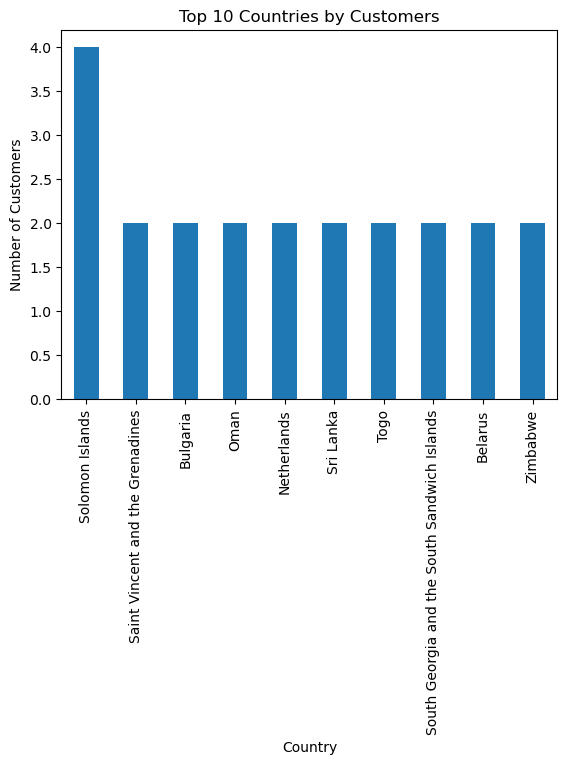

In [21]:
#Customers by Country (Bar Graph)
country_counts = df['Country'].value_counts().head(10)

country_counts.plot(kind='bar')

plt.title("Top 10 Countries by Customers")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

plt.show()

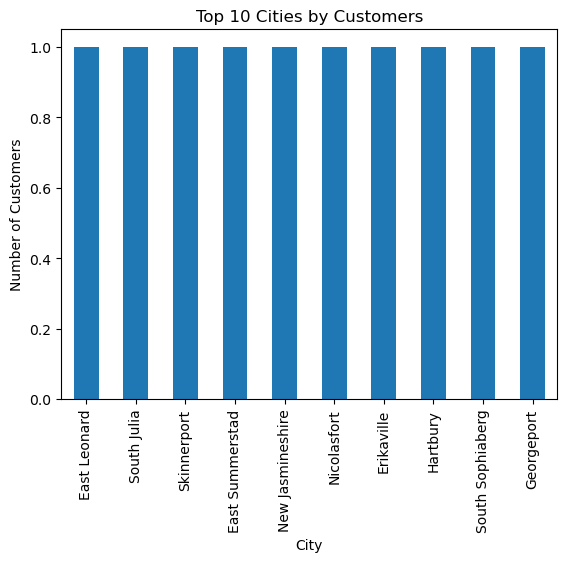

In [22]:
#Customers by City (Bar Graph)
city_counts = df['City'].value_counts().head(10)

city_counts.plot(kind='bar')

plt.title("Top 10 Cities by Customers")
plt.xlabel("City")
plt.ylabel("Number of Customers")

plt.show()

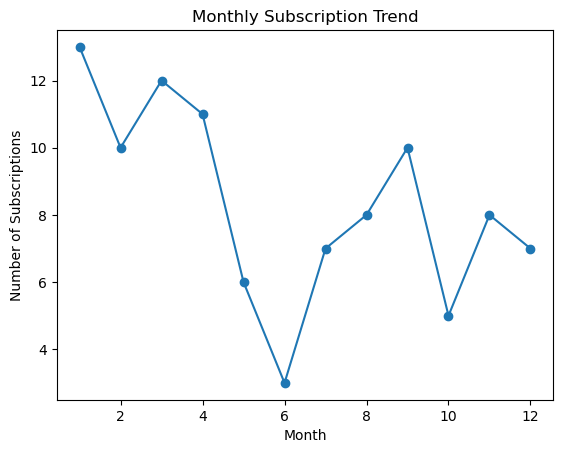

In [23]:
#Subscription Trend Over Time (Line Graph)
df['Subscription Date'] = pd.to_datetime(df['Subscription Date'])

monthly = df.groupby(df['Subscription Date'].dt.month).size()

monthly.plot(kind='line', marker='o')

plt.title("Monthly Subscription Trend")
plt.xlabel("Month")
plt.ylabel("Number of Subscriptions")

plt.show()

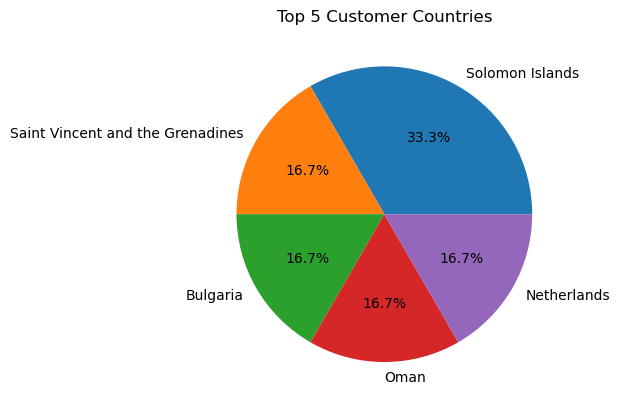

In [24]:
#Pie Chart of Top Countries
country_counts = df['Country'].value_counts().head(5)

country_counts.plot(kind='pie', autopct='%1.1f%%')

plt.title("Top 5 Customer Countries")

plt.ylabel("")

plt.show()

In [26]:
df.to_csv("cleaned_customers.csv", index=False)

print("Cleaned CSV file saved successfully")

Cleaned CSV file saved successfully
